# !Advertencia!
Este notebook es solo para realizar pruebas no es el Notebook Oficial del Modelo

## Preparacion de los datos

In [ ]:
# revisamos las imagenes para entrenar el modelo
import os
import random
import shutil

splitsize = .80
categories = []

source_folder = "/Users/jairpalma/Development/Reciclame/dataset-resized"
folders = os.listdir(source_folder)
print(folders)

for subfolder in folders:
    if os.path.isdir(source_folder + '/' + subfolder):
        categories.append(subfolder)

categories.sort()
print(categories)

target_folder = "/Users/jairpalma/Development/Reciclame/dataset_for_model"
existDataSetPath = os.path.exists(target_folder)

if existDataSetPath == False:
    os.mkdir(target_folder)

In [ ]:
import os
import random
import shutil

def split_data(SOURCE, TRAINING, VALIDATION, TESTING, TRAIN_RATIO=0.7, VAL_RATIO=0.15):
    """
    Divide los archivos válidos en Training, Validation y Testing.
    El remanente (1 - TRAIN_RATIO - VAL_RATIO) se asigna automáticamente a Testing.
    """
    files = []
    for filename in os.listdir(SOURCE):
        file_path = os.path.join(SOURCE, filename)
        
        # Ignorar directorios y archivos de tamaño 0
        if os.path.isfile(file_path):
            if os.path.getsize(file_path) > 0:
                files.append(filename)
            else:
                print(f"{filename} is 0 length, ignore it.....")
    
    total_files = len(files)
    print(f"Total valid files: {total_files}")
    
    if total_files == 0:
        return

    # Calcular puntos de corte
    train_length = int(total_files * TRAIN_RATIO)
    val_length = int(total_files * VAL_RATIO)
    
    # Barajar archivos
    shuffled_files = random.sample(files, total_files)
    
    # Segmentar listas
    training_set = shuffled_files[:train_length]
    val_set = shuffled_files[train_length : train_length + val_length]
    test_set = shuffled_files[train_length + val_length :]

    # Función auxiliar para copiar lotes de archivos
    def copy_subset(file_list, dest_dir):
        for filename in file_list:
            src = os.path.join(SOURCE, filename)
            dst = os.path.join(dest_dir, filename)
            shutil.copyfile(src, dst)

    # Copiar a sus respectivos directorios
    copy_subset(training_set, TRAINING)
    copy_subset(val_set, VALIDATION)
    copy_subset(test_set, TESTING)


# --- Preparación de carpetas y ejecución ---

# Rutas principales
trainPath = os.path.join(target_folder, 'train')
validatePath = os.path.join(target_folder, 'validate')
testPath = os.path.join(target_folder, 'test')

# Crear carpetas raíz si no existen
for path in [trainPath, validatePath, testPath]:
    os.makedirs(path, exist_ok=True)

# Proporciones (ejemplo: 70% train, 15% validation, 15% test)
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

# Iterar sobre cada categoría
for category in categories:
    trainDestPath = os.path.join(trainPath, category)
    validateDestPath = os.path.join(validatePath, category)
    testDestPath = os.path.join(testPath, category)

    # Crear subcarpetas de clase si no existen
    for path in [trainDestPath, validateDestPath, testDestPath]:
        os.makedirs(path, exist_ok=True)

    sourcePath = os.path.join(source_folder, category)

    print(f"\nProcessing category '{category}'...")
    print(f"From: {sourcePath}")
    print(f"To  : {trainDestPath}\n      {validateDestPath}\n      {testDestPath}")
    
    split_data(sourcePath, trainDestPath, validateDestPath, testDestPath, TRAIN_RATIO, VAL_RATIO)

In [ ]:
## TEST 
def split_data2(SOURCE, TRAINING, TEST, VALIDATION, SPLIT_SIZE):
        files = []
        for filename in os.listdir(SOURCE):
                file = SOURCE + filename
                print(file)
                if os.path.getsize(file) > 0 :
                        files.append(filename)
                else:
                        print(filename + " is 0 lenght, ignore it.....")
        print(len(files))
        trainingLength = int(len(files) * SPLIT_SIZE)
        testLenght = int(trainingLength * SPLIT_SIZE)
        shuffleSet = random.sample(files, len(files))
        trainingSet = shuffleSet[0:trainingLength]
        validSet = shuffleSet[trainingLength:]
        testSet = shuffleSet[0:testLenght]
        
        # copy images
        for filename in trainingSet:
                thisFile = SOURCE + filename
                destination = TRAINING + filename
                shutil.copyfile(thisFile, destination)

        for filename in validSet:
                thisFile = SOURCE + filename
                destination = VALIDATION + filename
                shutil.copyfile(thisFile, destination)

trainPath = target_folder + '/train'
validatePath = target_folder + '/validate'

#create folder
existDataSetPath = os.path.exists(trainPath)
if existDataSetPath == False:
        os.mkdir(trainPath)

existDataSetPath = os.path.exists(validatePath)
if existDataSetPath == False:
        os.mkdir(validatePath)

# for each folder
for category in categories:
        trainDestPath = trainPath + '/' + category
        validateDestPath = validatePath + '/' + category

        if os.path.exists(trainDestPath) == False:
                os.mkdir(trainDestPath)

        if os.path.exists(validateDestPath) == False:
                os.mkdir(validateDestPath)

        sourcePath = source_folder + '/' + category + '/'
        trainDestPath = trainDestPath + '/'
        validateDestPath = validateDestPath + '/'

        print("Copy from: "+sourcePath+" to: "+trainDestPath+" and "+validateDestPath)
        split_data(sourcePath, trainDestPath, validateDestPath, splitsize)


## Descargar y preparar el modelo

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)
print("TensorFlow Version:", tf.__version__)

# Check if the M1 GPU is recognized
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print("GPU Details:", gpus)

In [6]:
# Librerias
from tensorflow import keras
import tf2onnx
from keras.models import load_model
from keras import Model
from keras.applications import MobileNetV3Large, MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.optimizers import Adam

#### Data Augmentation

In [ ]:
trainPath = "/Users/jairpalma/Development/Reciclame/dataset_for_model/train"
validPath = "/Users/jairpalma/Development/Reciclame/dataset_for_model/validate"
testPath = "/Users/jairpalma/Development/Reciclame/dataset_for_model/test"

trainGenerator = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0, 0.4),
    #shear_range=.3,
    #zoom_range=[0, .4]
).flow_from_directory(trainPath, target_size=(224, 224), batch_size=32)

validGenerator = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0, 0.4),
    #shear_range=.3,
    #zoom_range=[0, .4]
).flow_from_directory(validPath, target_size=(224, 224), batch_size=32)

testGenerator = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=(0, 0.4),
    #shear_range=.3,
    #zoom_range=[0, .4]
).flow_from_directory(testPath, target_size=(224, 224), batch_size=32)

#### Creación del Modelo

In [ ]:
# create model
baseModel = MobileNetV3Small(weights = "imagenet", include_top = False, input_shape=(224, 224, 3))

x = baseModel.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
# x = MaxPooling2D()(x)
#x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
#x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
#x = Dropout(0.3)(x)
#x = Dense(64, activation='relu')(x)
#x = Dropout(0.2)(x)
#x = Conv2D(256, 3, input_shape= (224, 224, 3), activation='relu', padding="same")(x)
# x = MaxPooling2D(padding="same")(x)
#x = Dropout(0.2)(x)

#x = Conv2D(128, activation='relu', padding="same")(x)
# x = MaxPooling2D(padding="same")(x)
#x = Dropout(0.3)(x)
predictionLayer = Dense(6, activation='softmax')(x)
model = Model(inputs=baseModel.input, outputs=predictionLayer)

# model.summary()

#### Compilacion del modelo

In [ ]:
# Freeze the layers of the mobile net
for layer in model.layers[:5]:
    layer.trainable = False

# Compile
optimizer = Adam(learning_rate=0.0001)
#  sparse_categorical_crossentropy 
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=['accuracy'])

#### Entrenamiento del modelo y callbacks

In [ ]:
# Early stopping
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    # Checkpoint para guardar el mejor modelo
    tf.keras.callbacks.ModelCheckpoint(
        'best_transfer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

print('Entrenando modelo....')
history = model.fit(trainGenerator, 
                    validation_data=validGenerator, 
                    epochs=15, 
                    verbose=2,
                    callbacks=my_callbacks)

#### Guardado del modelo

In [ ]:
modelSavedPath = target_folder + "/mymodelV3.keras"
model.save(modelSavedPath)
print('Modelo guardado....')

# Pruebas y experimentos

## Transfer Learning

In [ ]:
# Cargar MobileNetV3Small preentrenado
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,  # No incluir la capa de clasificación original
    weights='imagenet'  # Pesos preentrenados en ImageNet
)

base_model.trainable = False

# Crear modelo completo
inputs = tf.keras.Input(shape=(224, 224, 3))

# Capa de entrada
x = inputs

# Aplicar capa de normalización (ya incluida en MobileNetV3Small)
x = base_model(x, training=False)

# Añadir capas personalizadas
# IMPORTANTE: Reducir complejidad para evitar sobreajuste
x = GlobalAveragePooling2D()(x)

# Regularización fuerte para evitar sobreajuste
x = Dropout(0.5)(x)  # Dropout alto

# Capa densa con regularización L2
x = Dense(512, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.3)(x)

# Capa densa con regularización L2
x = Dense(128, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.1)(x)

# Capa de salida
outputs = Dense(6, activation='softmax')(x)

# Creacion del modelo con las capas de salida y entrada
model = Model(inputs, outputs)

# Compile
optimizer = Adam(learning_rate=0.0001)
#  sparse_categorical_crossentropy 
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=['accuracy'])

# callbacks para el training
my_callbacks = [
    # Reduce learning rate en plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),
    # Checkpoint para guardar el mejor modelo
    tf.keras.callbacks.ModelCheckpoint(
        'best_transfer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]

# Entrenamiento del modelo
history = model.fit(trainGenerator, 
                    validation_data=validGenerator, 
                    epochs=50, 
                    verbose=2,
                    callbacks=my_callbacks,
                    batch_size = 128)

In [ ]:
# Guardado de modelo
modelSavedPath = target_folder + "/mymodelV3Large.keras"
model.save(modelSavedPath)
print("Modelo guardado.....")

### Test and Accuracy

In [ ]:
test_loss_ft, test_accuracy_ft = model.evaluate(testGenerator, verbose=0)
print(f"Test Accuracy: {test_accuracy_ft:.4f}")
print(f"Test Loss: {test_loss_ft:.4f}")

## Pruebas con Tf.data

#### Paso 1: Crear la partición (Train, Validation y Test)

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

DATA_DIR = "/Users/jairpalma/Development/Reciclame/dataset-resized"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

# 1. Obtener todas las rutas y sus etiquetas
class_names = []
folders = os.listdir(DATA_DIR)
for subfolder in folders:
    if os.path.isdir(os.path.join(DATA_DIR, subfolder)):
        class_names.append(subfolder)

class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

file_paths = []
labels = []

for cls_name in class_names:
    cls_folder = os.path.join(DATA_DIR, cls_name)
    if os.path.isdir(cls_folder):
        for fname in os.listdir(cls_folder):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_paths.append(os.path.join(cls_folder, fname))
                labels.append(class_to_idx[cls_name])

# 2. Dividir: 70% Train, 15% Validation, 15% Test (Estratificado)
# Primer corte: 70% Train, 30% Temporal (Val + Test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Segundo corte: Dividir el 30% a la mitad -> 15% Val y 15% Test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Total imágenes: {len(file_paths)}")
print(f"Entrenamiento : {len(train_paths)}")
print(f"Validación    : {len(val_paths)}")
print(f"Prueba (Test) : {len(test_paths)}")

Total imágenes: 2521
Entrenamiento : 1764
Validación    : 378
Prueba (Test) : 379


#### Paso 2: Crear el pipeline de datos optimizado con tf.data

In [2]:
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # MobileNetV3 espera entradas escaladas con su función respectiva
    img = keras.applications.mobilenet_v3.preprocess_input(img)
    return img, label

def create_dataset(paths, labels, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=SEED)
    
    # Cargar imágenes en paralelo
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    # shuffle=False en validación y test es VITAL para no desalinear predicciones
    return dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = create_dataset(train_paths, train_labels, is_training=True)
val_ds   = create_dataset(val_paths, val_labels, is_training=False)
test_ds  = create_dataset(test_paths, test_labels, is_training=False)

2026-09-09 14:40:48.087664: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-09-09 14:40:48.087701: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-09 14:40:48.087713: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-09-09 14:40:48.087739: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-09 14:40:48.087756: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Paso 3: Data Augmentation

In [4]:
import tensorflow as tf
from tensorflow import keras

# 1. Definir el pipeline de Data Augmentation
data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),       # Rotación aleatoria en rango [-10%, +10%]
        keras.layers.RandomZoom(0.1),           # Zoom aleatorio in/out
        keras.layers.RandomTranslation(0.05, 0.05), # Desplazamiento horizontal y vertical
        keras.layers.RandomContrast(0.1),       # Variación de contraste
    ],
    name="data_augmentation"
)

#### Paso 4: Definir y Entrenar MobileNetV3

##### Modelo 1 Large

In [12]:
# 2. Base preentrenada de MobileNetV3 Small
num_classes = len(class_names)

base_model = keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False  # Congelado para fase inicial

# 3. Ensamblar la arquitectura completa
inputs = keras.Input(shape=(224, 224, 3), name="input_image")

# Data augmentation se aplica primero (solo activo si training=True)
x = data_augmentation(inputs)

# MobileNetV3 con BatchNormalization congelada
x = base_model(x, training=False)

# Regularización y clasificación
x = keras.layers.Dropout(0.5)(x)

# Capa densa con regularización L2
x = Dense(512, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.3)(x)

# Capa densa con regularización L2
x = Dense(128, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

x = Dropout(0.1)(x)

outputs = keras.layers.Dense(num_classes, activation='softmax', name="predictions")(x)

model = keras.Model(inputs, outputs)

# 4. Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks útiles para evitar sobreajuste
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

# 6. Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


/opt/miniconda3/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 386ms/step - accuracy: 0.5420 - loss: 9.6294 - val_accuracy: 0.8016 - val_loss: 7.4363 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.6950 - loss: 6.9795 - val_accuracy: 0.8254 - val_loss: 5.6911 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.7126 - loss: 5.3963 - val_accuracy: 0.8016 - val_loss: 4.5198 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.7387 - loss: 4.2439 - val_accuracy: 0.8228 - val_loss: 3.5761 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.7585 - loss: 3.4169 - val_accuracy: 0.8386 - val_loss: 2.9066 - learning_rate: 0.0010
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 226ms/step - accuracy: 0.7613 - loss: 2.8534 - val_accuracy: 0.8413 - val_loss: 2.4433 - learning_rate: 0.0010
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.7772 - loss: 2.4052 - val_accura

##### Modelo 2 Small

In [ ]:
num_classes = len(class_names)

# Cargar MobileNetV3 Small
base_model = keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False  # Congelar base para transfer learning inicial

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar evaluando en Validation
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

#### Paso 5: Evaluar Métricas en Test (Precision, Recall, F1-Score)

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - accuracy: 0.8575 - loss: 0.9356
Test Loss:     0.9356
Test Accuracy: 85.75%


In [14]:
# 1. Obtener predicciones en el conjunto de test
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Las etiquetas reales corresponden exactamente a test_labels
# (dado que test_ds no fue mezclado/shuffled)
y_true = np.array(test_labels)

# 3. Reporte completo con Precision, Recall y F1-Score por clase y globales
report = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names,
    digits=4
)
print("=== CLASSIFICATION REPORT (TEST SET) ===")
print(report)

# 4. Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("=== CONFUSION MATRIX ===")
print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 543ms/step
=== CLASSIFICATION REPORT (TEST SET) ===
              precision    recall  f1-score   support

       paper     0.8190    0.9663    0.8866        89
       metal     0.8000    0.9677    0.8759        62
   cardboard     0.9600    0.7869    0.8649        61
       trash     0.7500    0.6000    0.6667        20
       glass     0.9077    0.7867    0.8429        75
     plastic     0.8824    0.8333    0.8571        72

    accuracy                         0.8575       379
   macro avg     0.8532    0.8235    0.8323       379
weighted avg     0.8645    0.8575    0.8555       379

=== CONFUSION MATRIX ===
[[86  0  2  1  0  0]
 [ 1 60  0  1  0  0]
 [13  0 48  0  0  0]
 [ 2  5  0 12  0  1]
 [ 1  8  0  0 59  7]
 [ 2  2  0  2  6 60]]


In [15]:
import matplotlib.pyplot as plt

def plot_history(history_base, title_accuracy = 'Transfer Learning Accuracy', title_loss = 'Transfer Learning Loss'):
    """Visualizar historial de entrenamiento"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Accuracy Transfer Learning
    ax1.plot(history_base.history['accuracy'], label='Train')
    ax1.plot(history_base.history['val_accuracy'], label='Val')
    ax1.set_title(title_accuracy)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss Transfer Learning
    ax2.plot(history_base.history['loss'], label='Train')
    ax2.plot(history_base.history['val_loss'], label='Val')
    ax2.set_title(title_loss)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

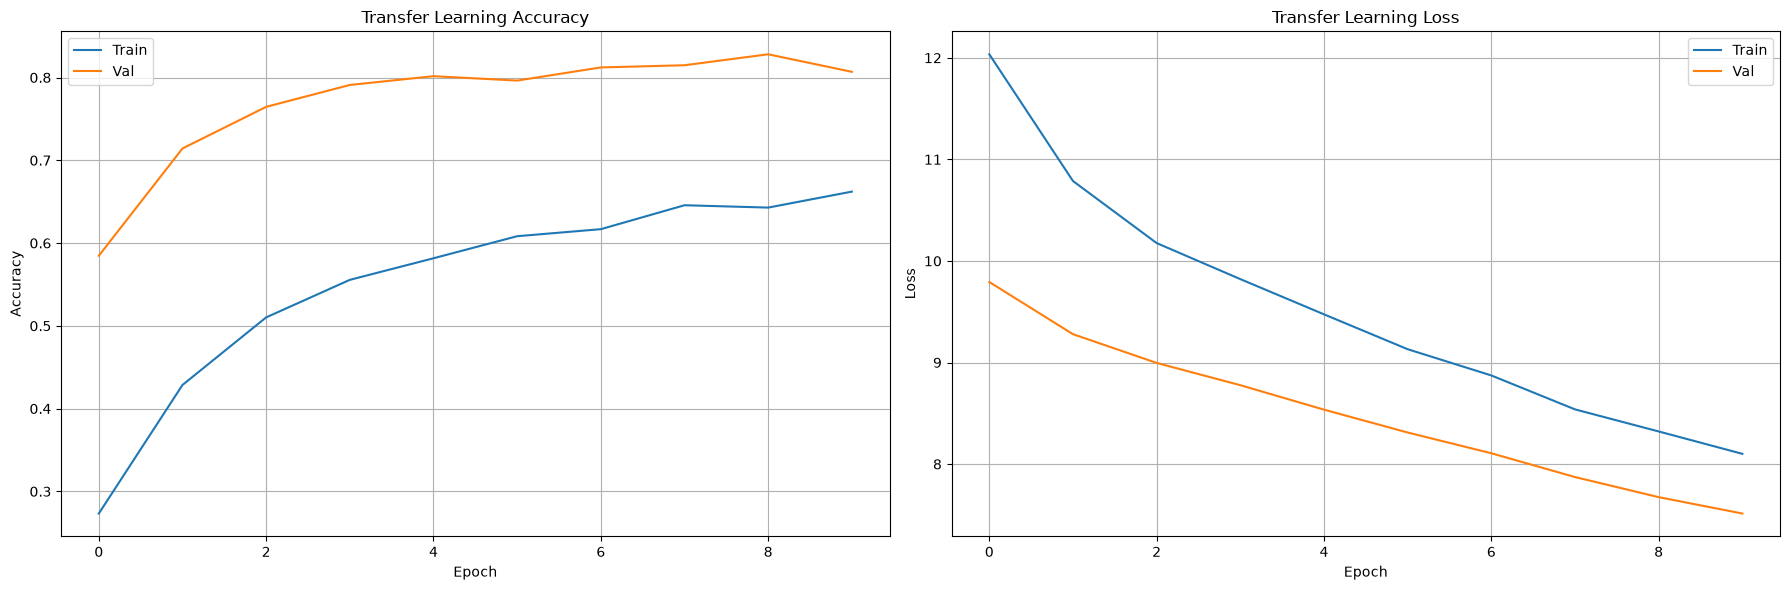

In [11]:
plot_history(history) #512

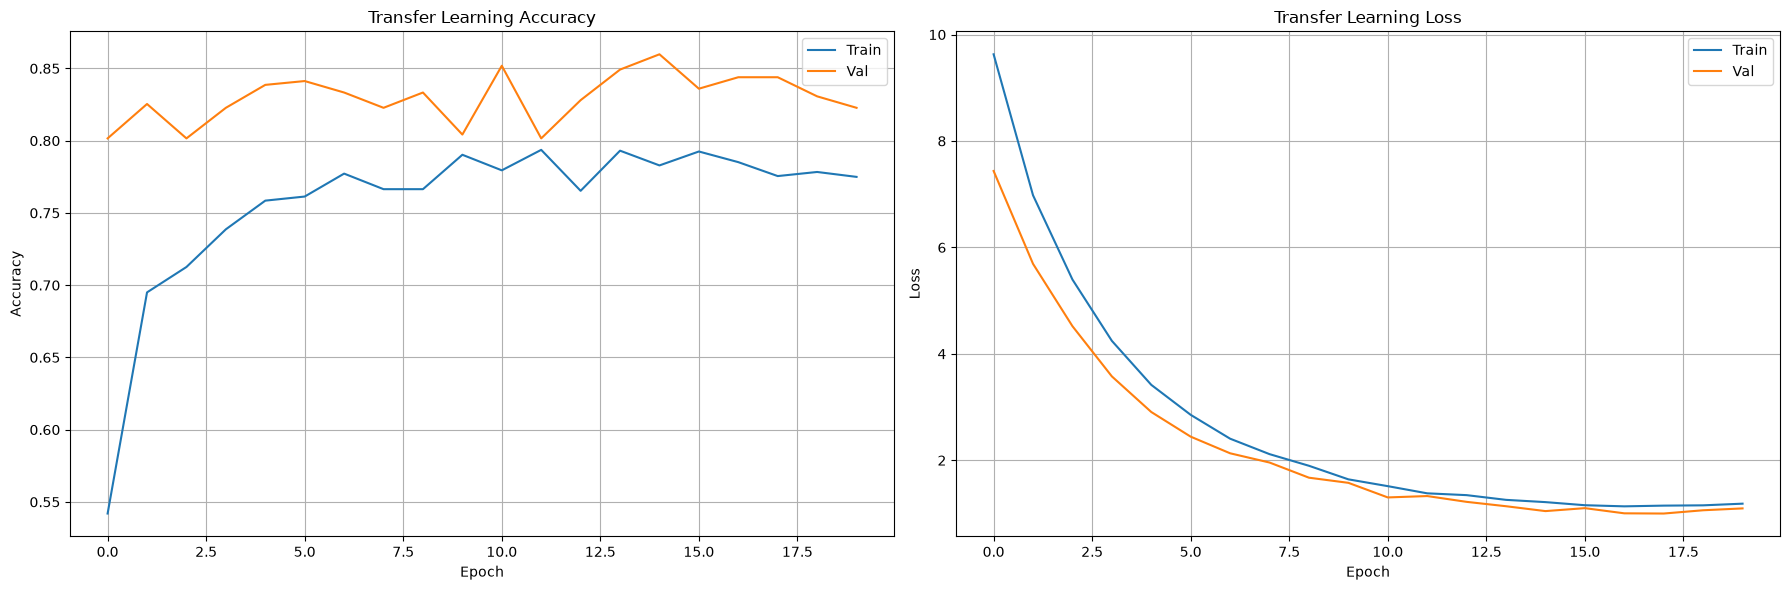

In [16]:
plot_history(history) #512

##### Paso 6. Guardar modelo

In [20]:
# Guardado de modelo
target_folder = "/Users/jairpalma/Development/Reciclame/dataset_for_model"
modelSavedPath = target_folder + "/mymodelV3Large.keras"
model.save(modelSavedPath)
print("Modelo guardado.....")

Modelo guardado.....


##### Paso 7. Realizar inferencias

/Users/jairpalma/Development/Reciclame/test_images/glass10.jpg
/Users/jairpalma/Development/Reciclame/test_images/metal.png
/Users/jairpalma/Development/Reciclame/test_images/papel.jpeg
/Users/jairpalma/Development/Reciclame/test_images/vidri.png
/Users/jairpalma/Development/Reciclame/test_images/cardboard13.jpg
/Users/jairpalma/Development/Reciclame/test_images/plastic.jpeg
/Users/jairpalma/Development/Reciclame/test_images/trash6.jpg
/Users/jairpalma/Development/Reciclame/test_images/plastic18.jpg
/Users/jairpalma/Development/Reciclame/test_images/glass19.jpg
/Users/jairpalma/Development/Reciclame/test_images/metal8.jpg
/Users/jairpalma/Development/Reciclame/test_images/trash.jpg
/Users/jairpalma/Development/Reciclame/test_images/cardboard.png
Total valid files: 12


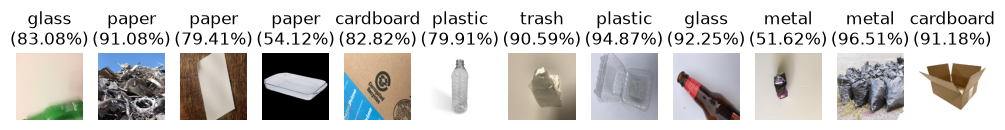

In [30]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir tus clases en el mismo orden que durante el entrenamiento
def predecir_imagen(image_path, model):
    # Cargar y redimensionar la imagen a 224x224
    img = keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = keras.utils.img_to_array(img)
    
    # Expandir dimensiones para simular el batch: de [224, 224, 3] a [1, 224, 224, 3]
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Preprocesamiento oficial de MobileNetV3
    img_preprocessed = keras.applications.mobilenet_v3.preprocess_input(img_batch)
    
    # Inferencia (training=False asegura que no se aplique data augmentation ni dropout)
    predictions = model(img_preprocessed, training=False).numpy()
    
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    predicted_label = class_names[class_idx]
    
    return img, predicted_label, confidence

# 2. Cargar tu modelo guardado
target_folder = "/Users/jairpalma/Development/Reciclame/dataset_for_model"
model_name = os.path.join(target_folder, "mymodelV3SkiLearn.keras")
model = keras.models.load_model(model_name)

# 3. Probar con una o varias imágenes
test_images_path = "/Users/jairpalma/Development/Reciclame/test_images/"
imagenes_prueba = []
for filename in os.listdir(test_images_path):
        file_path = os.path.join(test_images_path, filename)
        print(file_path)
        # Ignorar directorios y archivos de tamaño 0
        if os.path.isfile(file_path):
            if os.path.getsize(file_path) > 0:
                imagenes_prueba.append(file_path)
            else:
                print(f"{filename} is 0 length, ignore it.....")
    
total_files = len(imagenes_prueba)
print(f"Total valid files: {total_files}")

plt.figure(figsize=(10, 5))
for i, img_path in enumerate(imagenes_prueba):
    img, label, conf = predecir_imagen(img_path, model)
    
    plt.subplot(1, len(imagenes_prueba), i + 1)
    plt.imshow(img)
    plt.title(f"{label}\n({conf:.2f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [53]:
import onnxruntime as ort
import numpy as np
from PIL import Image

# 1. Inicializar sesión de ONNX Runtime
model_onnx = "mobilenetlarge-trash.onnx"
session = ort.InferenceSession(os.path.join(target_folder, model_onnx))

# 2. Cargar y preparar imagen en NCHW [1, 3, 224, 224]
img = Image.open("/Users/jairpalma/Development/Reciclame/test_images/vidri.png").convert("RGB").resize((224, 224))
arr = np.array(img, dtype=np.float32)

# Si tu exportación ya tiene la transposición interna, pasa [1, 3, 224, 224]:
# Transponer de HWC [224, 224, 3] a CHW [3, 224, 224]
arr_chw = np.transpose(arr, (2, 0, 1))
input_tensor = np.expand_dims(arr_chw, axis=0) # [1, 3, 224, 224]

# 3. Ejecutar sesión ONNX
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

preds = session.run([output_name], {input_name: input_tensor})[0]

"""
i = 0
for predictions in preds:
    for pred in predictions:
        print(f"Class: {class_names[i]} confidence: {(pred * 100):.2f}")
        i = i + 1
"""

# 4. Interpretar resultado
class_idx = np.argmax(preds[0])
confidence = np.max(preds[0]) * 100
print(f"Predicción ONNX: {class_names[class_idx]} ({confidence:.2f}%)")
print(class_names)

Predicción ONNX: paper (70.71%)
['paper', 'metal', 'cardboard', 'trash', 'glass', 'plastic']


### Exportar modelo a ONNX

In [22]:
model_onnx = target_folder + "/mobilenetlarge-trash.onnx"

# Load the model (works for .keras, .h5, or SavedModel directories)
model = load_model(modelSavedPath)

# 2. Definimos la firma con la forma estática exacta NCHW: [1, 3, 224, 224]
# tf.float32 equivale a System.Single en C#
input_signature = [
    tf.TensorSpec(shape=(1, 3, 224, 224), dtype=tf.float32, name="input")
]

# 3. Función envoltorio que transpone NCHW -> NHWC internamente
@tf.function(input_signature=input_signature)
def model_nchw(x):
    # Transponer de [batch, channels, height, width] a [batch, height, width, channels]
    x_nhwc = tf.transpose(x, perm=[0, 2, 3, 1])
    # Ejecutamos la inferencia (training=False desactiva dropout/batchnorm updates)
    preds = model(x_nhwc, training=False)
    # Si la salida no tiene nombre explícito o necesitas nombrarla:
    return tf.identity(preds, name="output")

# 4. Convertir a ONNX
# Recomendamos opset >= 13 para MobileNetV3 (por HardSwish/HardSigmoid)
onnx_model, _ = tf2onnx.convert.from_function(
    model_nchw,
    input_signature=input_signature,
    opset=17,  # 13, 16 o 17 son excelentes para ONNX Runtime moderno
    output_path=model_onnx
)

print("¡Modelo exportado con éxito!")

2026-09-09 15:01:53.173840: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-09-09 15:01:53.178593: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-09 15:01:53.178615: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-09 15:01:53.893909: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-09 15:01:53.893935: I tensorflow/core/com

¡Modelo exportado con éxito!
